# 08 — Evaluation
**Dự án:** Latent Manipulation of Brain MRI using Volume-Preserving GANs

**Metrics đánh giá 4 model:**
- **SSIM** — đo trên **test set** (không phải train set), dùng đúng indices đã lưu trong checkpoint
- **FID** (Fréchet Inception Distance) — đo phân bố ảnh fake vs ảnh thật trên test set
- **Loss_G** — WGAN loss Generator tốt nhất

**Output:**
```
evaluation/
├── metrics_summary.json
├── loss_curves.png
└── real_vs_fake.png
```

## Bước 1: Cấu hình

In [6]:
import os, json

# ==== CHECKPOINTS ====
MODEL_2D_NORM_PATH   = '/kaggle/input/datasets/cminhnguyndsdsds/conditional-gan2d-normalized/best_model.pth'
MODEL_2D_UNNORM_PATH = '/kaggle/input/datasets/dyio147/conditional-gan2d-unnormalized/best_model.pth'
MODEL_3D_NORM_PATH   = '/kaggle/input/datasets/cminhnguyndsdsds/conditional-gan3d-normalized/best_model.pth'
MODEL_3D_UNNORM_PATH = '/kaggle/input/datasets/dyio147/conditional-gan3d-unnormalized/best_model.pth'

# ==== DATA ====
DATA_2D_NORM_DIR   = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/normalized'
DATA_2D_UNNORM_DIR = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/unnormalized'
DATA_3D_NORM_DIR   = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/normalized'
DATA_3D_UNNORM_DIR = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/unnormalized'
LABELS_2D_CSV      = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/preprocessing_log.csv'
LABELS_3D_CSV      = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/preprocessing_log.csv'

OUTPUT_DIR = '/kaggle/working/evaluation'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LATENT_DIM = 256
print('Cấu hình xong!')


Cấu hình xong!


## Bước 2: Import thư viện

In [7]:
!pip install nibabel scikit-image -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## Bước 3: Định nghĩa kiến trúc model

In [8]:
class AgeEmbedding(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1,128), nn.ReLU(), nn.Linear(128,embed_dim))
    def forward(self, age): return self.net(age.unsqueeze(-1))

class UNetBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down: layers.append(nn.Conv2d(in_ch,out_ch,4,2,1,bias=False))
        else:    layers.append(nn.ConvTranspose2d(in_ch,out_ch,4,2,1,bias=False))
        if use_bn:  layers.append(nn.BatchNorm2d(out_ch))
        if dropout: layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

class UNetBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down: layers.append(nn.Conv3d(in_ch,out_ch,4,2,1,bias=False))
        else:    layers.append(nn.ConvTranspose3d(in_ch,out_ch,4,2,1,bias=False))
        if use_bn:  layers.append(nn.BatchNorm3d(out_ch))
        if dropout: layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

# ── U-Net cũ ──────────────────────────────────────────────────
class Generator2D(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed=AgeEmbedding(latent_dim); self.age_proj=nn.Linear(latent_dim,512)
        self.e1=UNetBlock2D(1,64,down=True,use_bn=False); self.e2=UNetBlock2D(64,128,down=True)
        self.e3=UNetBlock2D(128,256,down=True); self.e4=UNetBlock2D(256,512,down=True)
        self.e5=UNetBlock2D(512,512,down=True); self.e6=UNetBlock2D(512,512,down=True)
        self.e7=UNetBlock2D(512,512,down=True); self.e8=UNetBlock2D(512,512,down=True,use_bn=False)
        self.d1=UNetBlock2D(512,512,down=False,dropout=True); self.d2=UNetBlock2D(1024,512,down=False,dropout=True)
        self.d3=UNetBlock2D(1024,512,down=False,dropout=True); self.d4=UNetBlock2D(1024,512,down=False)
        self.d5=UNetBlock2D(1024,256,down=False); self.d6=UNetBlock2D(512,128,down=False)
        self.d7=UNetBlock2D(256,64,down=False)
        self.out=nn.Sequential(nn.ConvTranspose2d(128,1,4,2,1),nn.Tanh())
    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        z=e8+self.age_proj(self.age_embed(age)).view(-1,512,1,1)
        d1=self.d1(z); d2=self.d2(torch.cat([d1,e7],1)); d3=self.d3(torch.cat([d2,e6],1))
        d4=self.d4(torch.cat([d3,e5],1)); d5=self.d5(torch.cat([d4,e4],1))
        d6=self.d6(torch.cat([d5,e3],1)); d7=self.d7(torch.cat([d6,e2],1))
        return self.out(torch.cat([d7,e1],1))

class Generator3D(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed=AgeEmbedding(latent_dim); self.age_proj=nn.Linear(latent_dim,256)
        self.e1=UNetBlock3D(1,32,down=True,use_bn=False); self.e2=UNetBlock3D(32,64,down=True)
        self.e3=UNetBlock3D(64,128,down=True); self.e4=UNetBlock3D(128,256,down=True,use_bn=False)
        self.d1=UNetBlock3D(256,128,down=False,dropout=True)
        self.d2=UNetBlock3D(256,64,down=False); self.d3=UNetBlock3D(128,32,down=False)
        self.out=nn.Sequential(nn.ConvTranspose3d(64,1,4,2,1),nn.Tanh())
    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        z=e4+self.age_proj(self.age_embed(age)).view(-1,256,1,1,1)
        d1=self.d1(z); d2=self.d2(torch.cat([d1,e3],1)); d3=self.d3(torch.cat([d2,e2],1))
        return self.out(torch.cat([d3,e1],1))

# ── Concat (age_fuse) ─────────────────────────────────────────
class Generator2D_Concat(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed=AgeEmbedding(latent_dim); self.age_proj=nn.Linear(latent_dim,512)
        self.age_fuse=nn.Conv2d(1024,512,1)
        self.e1=UNetBlock2D(1,64,down=True,use_bn=False); self.e2=UNetBlock2D(64,128,down=True)
        self.e3=UNetBlock2D(128,256,down=True); self.e4=UNetBlock2D(256,512,down=True)
        self.e5=UNetBlock2D(512,512,down=True); self.e6=UNetBlock2D(512,512,down=True)
        self.e7=UNetBlock2D(512,512,down=True); self.e8=UNetBlock2D(512,512,down=True,use_bn=False)
        self.d1=UNetBlock2D(512,512,down=False,dropout=True); self.d2=UNetBlock2D(1024,512,down=False,dropout=True)
        self.d3=UNetBlock2D(1024,512,down=False,dropout=True); self.d4=UNetBlock2D(1024,512,down=False)
        self.d5=UNetBlock2D(1024,256,down=False); self.d6=UNetBlock2D(512,128,down=False)
        self.d7=UNetBlock2D(256,64,down=False)
        self.out=nn.Sequential(nn.ConvTranspose2d(128,1,4,2,1),nn.Tanh())
    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        age_feat=self.age_proj(self.age_embed(age)).view(-1,512,1,1).expand_as(e8)
        z=self.age_fuse(torch.cat([e8,age_feat],dim=1))
        d1=self.d1(z); d2=self.d2(torch.cat([d1,e7],1)); d3=self.d3(torch.cat([d2,e6],1))
        d4=self.d4(torch.cat([d3,e5],1)); d5=self.d5(torch.cat([d4,e4],1))
        d6=self.d6(torch.cat([d5,e3],1)); d7=self.d7(torch.cat([d6,e2],1))
        return self.out(torch.cat([d7,e1],1))

class Generator3D_Concat(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed=AgeEmbedding(latent_dim); self.age_proj=nn.Linear(latent_dim,256)
        self.age_fuse=nn.Conv3d(512,256,1)
        self.e1=UNetBlock3D(1,32,down=True,use_bn=False); self.e2=UNetBlock3D(32,64,down=True)
        self.e3=UNetBlock3D(64,128,down=True); self.e4=UNetBlock3D(128,256,down=True,use_bn=False)
        self.d1=UNetBlock3D(256,128,down=False,dropout=True)
        self.d2=UNetBlock3D(256,64,down=False); self.d3=UNetBlock3D(128,32,down=False)
        self.out=nn.Sequential(nn.ConvTranspose3d(64,1,4,2,1),nn.Tanh())
    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        age_feat=self.age_proj(self.age_embed(age)).view(-1,256,1,1,1).expand_as(e4)
        z=self.age_fuse(torch.cat([e4,age_feat],dim=1))
        d1=self.d1(z); d2=self.d2(torch.cat([d1,e3],1)); d3=self.d3(torch.cat([d2,e2],1))
        return self.out(torch.cat([d3,e1],1))

def load_model_2d(path):
    ckpt=torch.load(path,map_location=DEVICE); keys=list(ckpt['G_state'].keys())
    if any('age_fuse' in k for k in keys): G=Generator2D_Concat(LATENT_DIM).to(DEVICE)
    else:                                   G=Generator2D(LATENT_DIM).to(DEVICE)
    G.load_state_dict(ckpt['G_state']); G.eval(); return G, ckpt

def load_model_3d(path):
    ckpt=torch.load(path,map_location=DEVICE); keys=list(ckpt['G_state'].keys())
    if any('age_fuse' in k for k in keys): G=Generator3D_Concat(LATENT_DIM).to(DEVICE)
    else:                                   G=Generator3D(LATENT_DIM).to(DEVICE)
    G.load_state_dict(ckpt['G_state']); G.eval(); return G, ckpt

print('Model definitions xong!')

Model definitions xong!


## Bước 4: Dataset — dùng đúng Test Set từ checkpoint

Các model đã lưu `test_indices` khi train. Evaluation chỉ chạy trên phần data **chưa từng thấy** trong training.

In [9]:
def find_nii(data_dir, subject_id):
    for ext in ['.nii.gz', '.nii']:
        p = os.path.join(data_dir, f'{subject_id}{ext}')
        if os.path.exists(p): return p
    return None

class Dataset2D(Dataset):
    def __init__(self, data_dir, labels_csv, age_min, age_max, indices=None):
        self.age_min=age_min; self.age_max=age_max; self.data_dir=data_dir
        df=pd.read_csv(labels_csv)
        df['full_path']=df['png_file'].apply(lambda x: os.path.join(data_dir,x))
        df=df[df['full_path'].apply(os.path.exists)].reset_index(drop=True)
        self.df=df.iloc[indices] if indices is not None else df
        self.transform=transforms.Compose([
            transforms.Resize((256,256)), transforms.ToTensor(),
            transforms.Normalize([0.5],[0.5])
        ])
    def normalize_age(self, age):
        return 2*(age-self.age_min)/(self.age_max-self.age_min)-1
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=self.transform(Image.open(row['full_path']).convert('L'))
        return img, torch.tensor(self.normalize_age(row['age']), dtype=torch.float32)

class Dataset3D(Dataset):
    def __init__(self, data_dir, labels_csv, age_min, age_max, volume_size, indices=None):
        self.age_min=age_min; self.age_max=age_max; self.volume_size=volume_size
        df=pd.read_csv(labels_csv)
        df['nii_path']=df['subject_id'].apply(lambda x: find_nii(data_dir,x))
        df=df[df['nii_path'].notna()].reset_index(drop=True)
        self.df=df.iloc[indices] if indices is not None else df
    def normalize_age(self, age):
        return 2*(age-self.age_min)/(self.age_max-self.age_min)-1
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        data=nib.load(row['nii_path']).get_fdata().astype(np.float32)
        vol=torch.tensor(data).unsqueeze(0).unsqueeze(0)
        vol=F.interpolate(vol,size=(self.volume_size,)*3,mode='trilinear',align_corners=False)
        vol=(vol.squeeze(0)*2-1)
        return vol, torch.tensor(self.normalize_age(row['age']), dtype=torch.float32)

def make_loader_2d(data_dir, labels_csv, ckpt, batch_size=8):
    ds=Dataset2D(data_dir, labels_csv, ckpt['age_min'], ckpt['age_max'],
                 indices=ckpt.get('test_indices'))
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

def make_loader_3d(data_dir, labels_csv, ckpt, batch_size=1):
    ds=Dataset3D(data_dir, labels_csv, ckpt['age_min'], ckpt['age_max'],
                 ckpt.get('volume_size',64), indices=ckpt.get('test_indices'))
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

print('Dataset definitions xong!')

Dataset definitions xong!


## Bước 5: Tính SSIM + FID trên Test Set

In [10]:
def eval_ssim_2d(G, loader, device):
    scores=[]; G.eval()
    with torch.no_grad():
        for imgs, ages in tqdm(loader, desc='SSIM 2D', leave=False):
            imgs=imgs.to(device); ages=ages.to(device)
            fakes=G(imgs, ages)
            for i in range(imgs.size(0)):
                r=(imgs[i,0].cpu().numpy()+1)/2
                f=(fakes[i,0].cpu().numpy()+1)/2
                scores.append(ssim(r, f, data_range=1.0))
    return float(np.mean(scores))

def eval_ssim_3d(G, loader, device):
    scores=[]; G.eval()
    with torch.no_grad():
        for vols, ages in tqdm(loader, desc='SSIM 3D', leave=False):
            vols=vols.to(device); ages=ages.to(device)
            fakes=G(vols, ages)
            r=(vols[0,0].cpu().numpy()+1)/2
            f=(fakes[0,0].cpu().numpy()+1)/2
            scores.append(float(np.mean([ssim(r[i],f[i],data_range=1.0) for i in range(r.shape[0])])))
    return float(np.mean(scores))

def compute_psnr(r, f):
    mse=np.mean((r-f)**2)
    return float('inf') if mse==0 else float(20*np.log10(1.0/np.sqrt(mse)))

def eval_psnr_2d(G, loader, device):
    scores=[]; G.eval()
    with torch.no_grad():
        for imgs, ages in tqdm(loader, desc='PSNR 2D', leave=False):
            imgs=imgs.to(device); ages=ages.to(device); fakes=G(imgs,ages)
            for i in range(imgs.size(0)):
                r=(imgs[i,0].cpu().numpy()+1)/2; f=(fakes[i,0].cpu().numpy()+1)/2
                scores.append(compute_psnr(r,f))
    return float(np.mean(scores))

def eval_psnr_3d(G, loader, device):
    scores=[]; G.eval()
    with torch.no_grad():
        for vols, ages in tqdm(loader, desc='PSNR 3D', leave=False):
            vols=vols.to(device); ages=ages.to(device); fakes=G(vols,ages)
            r=(vols[0,0].cpu().numpy()+1)/2; f=(fakes[0,0].cpu().numpy()+1)/2
            scores.append(compute_psnr(r,f))
    return float(np.mean(scores))

def eval_vps_2d(G, loader, device):
    ratios=[]; G.eval()
    with torch.no_grad():
        for imgs, ages in tqdm(loader, desc='VPS 2D', leave=False):
            imgs=imgs.to(device); ages=ages.to(device); fakes=G(imgs,ages)
            for i in range(imgs.size(0)):
                r=(imgs[i,0].cpu().numpy()+1)/2; f=(fakes[i,0].cpu().numpy()+1)/2
                if r.sum()>0: ratios.append(f.sum()/r.sum())
    mean_ratio=float(np.mean(ratios))
    return 1.0-abs(1.0-mean_ratio), mean_ratio

def eval_vps_3d(G, loader, device):
    ratios=[]; G.eval()
    with torch.no_grad():
        for vols, ages in tqdm(loader, desc='VPS 3D', leave=False):
            vols=vols.to(device); ages=ages.to(device); fakes=G(vols,ages)
            r=(vols[0,0].cpu().numpy()+1)/2; f=(fakes[0,0].cpu().numpy()+1)/2
            if r.sum()>0: ratios.append(f.sum()/r.sum())
    mean_ratio=float(np.mean(ratios))
    return 1.0-abs(1.0-mean_ratio), mean_ratio

print('Metric functions xong!')

Metric functions xong!


In [11]:
# Load 4 models
print('Loading models...')
G2D_norm,   ck2n = load_model_2d(MODEL_2D_NORM_PATH)
G2D_unnorm, ck2u = load_model_2d(MODEL_2D_UNNORM_PATH)
G3D_norm,   ck3n = load_model_3d(MODEL_3D_NORM_PATH)
G3D_unnorm, ck3u = load_model_3d(MODEL_3D_UNNORM_PATH)
print(f'2D Norm   epoch={ck2n["epoch"]} | SSIM={ck2n.get("best_val_ssim",-1):.4f}')
print(f'2D Unnorm epoch={ck2u["epoch"]} | SSIM={ck2u.get("best_val_ssim",-1):.4f}')
print(f'3D Norm   epoch={ck3n["epoch"]} | SSIM={ck3n.get("best_val_ssim",-1):.4f}')
print(f'3D Unnorm epoch={ck3u["epoch"]} | SSIM={ck3u.get("best_val_ssim",-1):.4f}')

# Tạo loaders
print('Tạo loaders...')
loader_2d_norm   = make_loader_2d(DATA_2D_NORM_DIR,   LABELS_2D_CSV, ck2n)
loader_2d_unnorm = make_loader_2d(DATA_2D_UNNORM_DIR, LABELS_2D_CSV, ck2u)
loader_3d_norm   = make_loader_3d(DATA_3D_NORM_DIR,   LABELS_3D_CSV, ck3n)
loader_3d_unnorm = make_loader_3d(DATA_3D_UNNORM_DIR, LABELS_3D_CSV, ck3u)
print('Loaders sẵn sàng!')

# Tính metrics
print('\nTính SSIM...')
ssim_2n = eval_ssim_2d(G2D_norm,   loader_2d_norm,   DEVICE)
ssim_2u = eval_ssim_2d(G2D_unnorm, loader_2d_unnorm, DEVICE)
ssim_3n = eval_ssim_3d(G3D_norm,   loader_3d_norm,   DEVICE)
ssim_3u = eval_ssim_3d(G3D_unnorm, loader_3d_unnorm, DEVICE)

print('Tính PSNR...')
psnr_2n = eval_psnr_2d(G2D_norm,   loader_2d_norm,   DEVICE)
psnr_2u = eval_psnr_2d(G2D_unnorm, loader_2d_unnorm, DEVICE)
psnr_3n = eval_psnr_3d(G3D_norm,   loader_3d_norm,   DEVICE)
psnr_3u = eval_psnr_3d(G3D_unnorm, loader_3d_unnorm, DEVICE)

print('Tính VPS...')
vps_2n, ratio_2n = eval_vps_2d(G2D_norm,   loader_2d_norm,   DEVICE)
vps_2u, ratio_2u = eval_vps_2d(G2D_unnorm, loader_2d_unnorm, DEVICE)
vps_3n, ratio_3n = eval_vps_3d(G3D_norm,   loader_3d_norm,   DEVICE)
vps_3u, ratio_3u = eval_vps_3d(G3D_unnorm, loader_3d_unnorm, DEVICE)

results = {
    'GAN_2D_normalized'  : {'epoch':ck2n['epoch'],'ssim':ssim_2n,'psnr':psnr_2n,'vps':vps_2n,'vol_ratio':ratio_2n},
    'GAN_2D_unnormalized': {'epoch':ck2u['epoch'],'ssim':ssim_2u,'psnr':psnr_2u,'vps':vps_2u,'vol_ratio':ratio_2u},
    'GAN_3D_normalized'  : {'epoch':ck3n['epoch'],'ssim':ssim_3n,'psnr':psnr_3n,'vps':vps_3n,'vol_ratio':ratio_3n},
    'GAN_3D_unnormalized': {'epoch':ck3u['epoch'],'ssim':ssim_3u,'psnr':psnr_3u,'vps':vps_3u,'vol_ratio':ratio_3u},
}

print('\n' + '='*75)
print('EVALUATION SUMMARY')
print('='*75)
print(f'{"Model":<25} {"Epoch":>6} {"SSIM↑":>8} {"PSNR↑":>8} {"VPS↑":>8} {"VolRatio":>10}')
print('-'*75)
for name, m in results.items():
    print(f'{name:<25} {m["epoch"]:>6} {m["ssim"]:>8.4f} {m["psnr"]:>8.2f} {m["vps"]:>8.4f} {m["vol_ratio"]:>10.4f}')
print('='*75)
print('SSIM↑ & PSNR↑: cao hơn tốt hơn | VPS↑: gần 1.0 = volume preserved')

with open(f'{OUTPUT_DIR}/metrics_summary.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nKết quả lưu: {OUTPUT_DIR}/metrics_summary.json')

Loading models...
2D Norm   epoch=44 | SSIM=0.9778
2D Unnorm epoch=22 | SSIM=0.9751
3D Norm   epoch=13 | SSIM=0.9734
3D Unnorm epoch=23 | SSIM=0.9805
Tạo loaders...
Loaders sẵn sàng!

Tính SSIM...


Tính PSNR...


Tính VPS...



EVALUATION SUMMARY
Model                      Epoch    SSIM↑    PSNR↑     VPS↑   VolRatio
---------------------------------------------------------------------------
GAN_2D_normalized             44   0.9801    35.11   0.9984     0.9984
GAN_2D_unnormalized           22   0.9750    36.30   0.9982     0.9982
GAN_3D_normalized             13   0.9734    30.95   0.9915     0.9915
GAN_3D_unnormalized           23   0.9805    32.77   0.9974     1.0026
SSIM↑ & PSNR↑: cao hơn tốt hơn | VPS↑: gần 1.0 = volume preserved

Kết quả lưu: /kaggle/working/evaluation/metrics_summary.json


## Bước 6: Loss Curves — 4 model

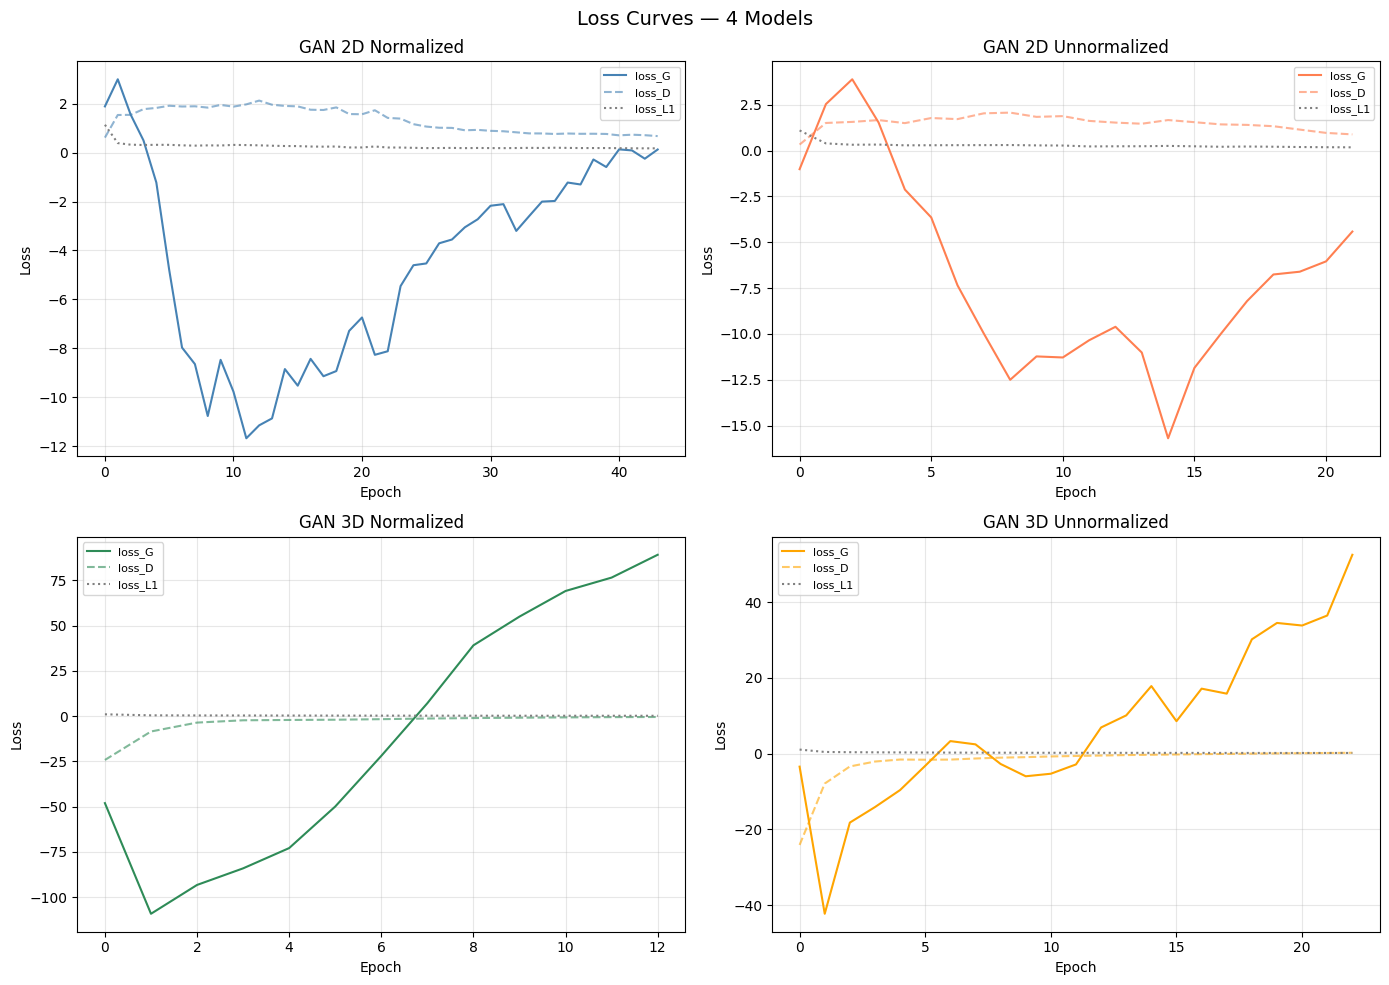

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Loss Curves — 4 Models', fontsize=14)

models = [
    (ck2n['history'], 'GAN 2D Normalized',   'steelblue'),
    (ck2u['history'], 'GAN 2D Unnormalized', 'coral'),
    (ck3n['history'], 'GAN 3D Normalized',   'seagreen'),
    (ck3u['history'], 'GAN 3D Unnormalized', 'orange'),
]

for ax, (hist, label, color) in zip(axes.flat, models):
    ax.plot(hist['loss_G'],  label='loss_G',  color=color)
    ax.plot(hist['loss_D'],  label='loss_D',  color=color, linestyle='--', alpha=0.6)
    ax.plot(hist['loss_L1'], label='loss_L1', color='gray', linestyle=':')
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/loss_curves.png', dpi=100)
plt.show()


## Bước 7: So sánh SSIM và Loss_G

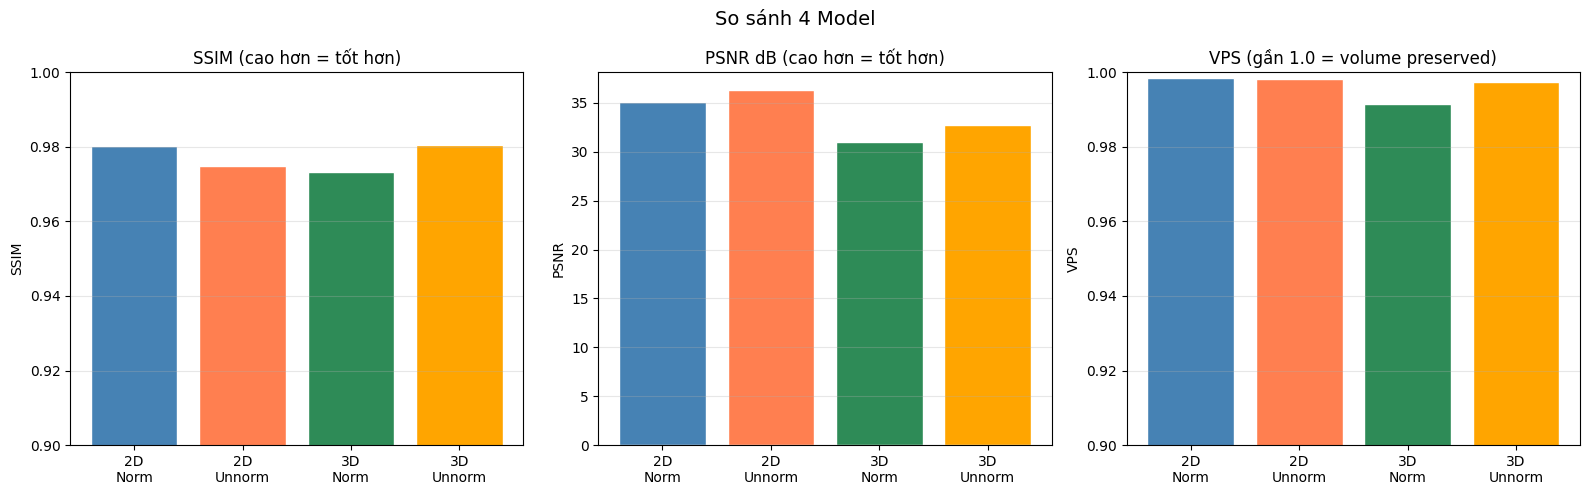

In [15]:
names       = list(results.keys())
short_names = ['2D\nNorm', '2D\nUnnorm', '3D\nNorm', '3D\nUnnorm']
ssim_vals   = [results[n]['ssim'] for n in names]
psnr_vals   = [results[n]['psnr'] for n in names]
vps_vals    = [results[n]['vps']  for n in names]
colors      = ['steelblue', 'coral', 'seagreen', 'orange']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('So sánh 4 Model', fontsize=14)

axes[0].bar(short_names, ssim_vals, color=colors, edgecolor='white')
axes[0].set_title('SSIM (cao hơn = tốt hơn)')
axes[0].set_ylabel('SSIM')
axes[0].set_ylim(0.9, 1.0)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(short_names, psnr_vals, color=colors, edgecolor='white')
axes[1].set_title('PSNR dB (cao hơn = tốt hơn)')
axes[1].set_ylabel('PSNR')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(short_names, vps_vals, color=colors, edgecolor='white')
axes[2].set_title('VPS (gần 1.0 = volume preserved)')
axes[2].set_ylabel('VPS')
axes[2].set_ylim(0.9, 1.0)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/comparison_chart.png', dpi=100)
plt.show()

## Bước 8: Real vs Fake — Kiểm tra chất lượng ảnh sinh ra

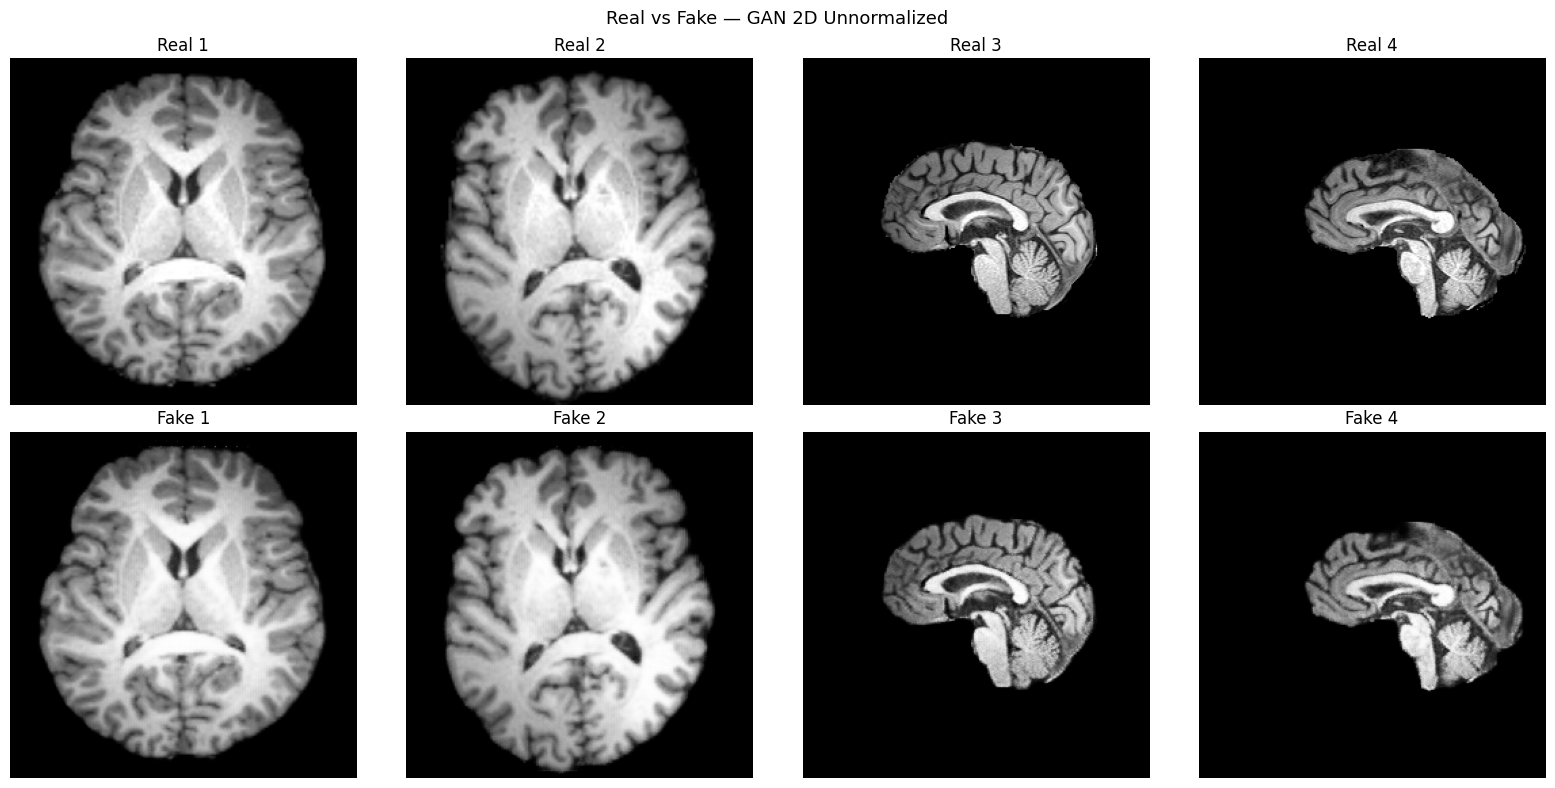

In [14]:
# Lấy 4 sample từ loader 2D unnormalized (model tốt nhất 2D)
G2D_unnorm.eval()
real_samples, age_samples = next(iter(loader_2d_unnorm))
real_samples = real_samples[:4].to(DEVICE)
age_samples  = age_samples[:4].to(DEVICE)

with torch.no_grad():
    fake_samples = G2D_unnorm(real_samples, age_samples)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Real vs Fake — GAN 2D Unnormalized', fontsize=13)

for i in range(4):
    real_np = (real_samples[i, 0].cpu().numpy() + 1) / 2
    fake_np = (fake_samples[i, 0].cpu().numpy() + 1) / 2

    axes[0][i].imshow(real_np, cmap='gray')
    axes[0][i].set_title(f'Real {i+1}')
    axes[0][i].axis('off')

    axes[1][i].imshow(fake_np, cmap='gray')
    axes[1][i].set_title(f'Fake {i+1}')
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/real_vs_fake.png', dpi=100)
plt.show()
